# 第19课 · 🎨 亲眼看见矩阵搬动整个空间——旋转、缩放、剪切与「列的线性组合」图解

> 视觉语言来自 **《The Art of Linear Algebra》**(Hiranabe & Strang)。

用 `laviz` 把矩阵/向量（vector）运算画成图，建立「矩阵×向量 = 列的线性组合」的空间直觉。Aurora 的 mel 滤波器矩阵 `M @ stft` 和 DFT 矩阵 `W @ x` 都是这张图的直接实例。

**学习目标**
1. 用 `laviz` 的 `matrix_4ways` 观察同一矩阵的四种读法（整体/数字/列/行）
2. 区分向量×向量的内积（→标量）和外积（→秩1矩阵）两种运算
3. 用 `mat_times_vec` 可视化矩阵×向量 = A 各列的线性组合，理解系数含义
4. 用 `mat_times_mat_rank1` 把矩阵乘法拆成秩1矩阵之和，建立 SVD/LoRA 的几何直觉
5. 将 mel 滤波器矩阵 `M @ stft` 和 DFT 矩阵 `W @ x` 映射到「列的线性组合」这张图

**为什么对 Aurora 重要**：mel 滤波器 `M @ stft` 和 DFT 矩阵 `W @ x` 都是这张图的直接实例；理解线性组合的几何含义，L21 的矩阵音频处理就有了形象基础。

← **上一课**　[L18 · 可逆性与秩](L18_invertibility.ipynb)

> 上节课学习了 **可逆性与秩**：秩 = 信息量，零空间 = 被压缩的方向，奇异矩阵诊断。  
> 本课将探讨 **矩阵变换图解**。

## 本课剧情：让空间动起来（L12 的眼睛版）

> **读法**：矩阵乘法的代数在 L12 已写过。本课**以图为主**——旋转、缩放、剪切长什么样；旁白保持短，不必重读 L12 全文。

矩阵乘法的几何核心只有一句话：盯住基向量被送到哪里，其余所有向量都随之移动。这节课用 `laviz` 把这个过程画出来——从「一个矩阵有几种读法」到「矩阵×矩阵 = 秩1矩阵之和」，逐步建立空间变换的视觉语言。

## 0. 载入工具（统一配色与版式）

## 符号入口：先看形状，再看运算

线性代数里的对象都有明确形状：向量是 `(n,)`，矩阵是 `(m, n)`，矩阵乘向量会把 `(n,)` 变成 `(m,)`。每个例子都先标出输入、变换和输出。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
from aurora.laviz import (style, matrix_4ways, vec_times_vec,
                   mat_times_vec, mat_times_mat_rank1)
style()
print('laviz 就绪')

laviz 就绪


## 动手观察：线代对象先看形状，再看意义

检查每个对象的 `.shape`：`v.shape` 告诉你向量的维度，`A.shape` 告诉你矩阵把多少维输入映射到多少维输出。对着下面的代码数一遍，矩阵乘法的维度就不会出错。

In [3]:
import numpy as np

v = np.array([3.0, 4.0])
A = np.array([[2.0, 0.0],
              [0.0, 0.5]])

print('v =', v, 'shape =', v.shape)
print('A =')
print(A)
print('A shape =', A.shape)
print('A @ v =', A @ v)
print('向量长度 ||v|| =', np.linalg.norm(v))


v = [3. 4.] shape = (2,)
A =
[[2.  0. ]
 [0.  0.5]]
A shape = (2, 2)
A @ v = [6. 2.]
向量长度 ||v|| = 5.0


## 代码实验：遍历几个向量，观察矩阵如何改变它们

同一个矩阵作用于不同向量时，方向和模长各自如何变化——把结果并排打印出来看规律。

In [4]:
import numpy as np

A = np.array([[2.0, 1.0],
              [0.0, 1.0]])
vectors = [np.array([1.0, 0.0]), np.array([0.0, 1.0]), np.array([1.0, 1.0]), np.array([2.0, -1.0])]

print('A =')
print(A)
for v in vectors:
    out = A @ v
    print(f'v={v} -> A@v={out}')


A =
[[2. 1.]
 [0. 1.]]
v=[1. 0.] -> A@v=[2. 0.]
v=[0. 1.] -> A@v=[1. 1.]
v=[1. 1.] -> A@v=[3. 1.]
v=[ 2. -1.] -> A@v=[ 3. -1.]


## 1. 一个矩阵的 4 种看法

整体 / mn 个数字 / **n 个列** / **m 个行**。后面所有运算，都在这几种看法之间切换。

为什么从"列"出发？矩阵乘法的几何本质是把基向量 `[1,0]` 和 `[0,1]` 各自映射到新位置——其余所有向量的变换都由这两列唯一确定。`laviz` 把变换前后的基向量并排显示，让「矩阵 = 坐标系变换」的直觉直接可见，不需要背公式。

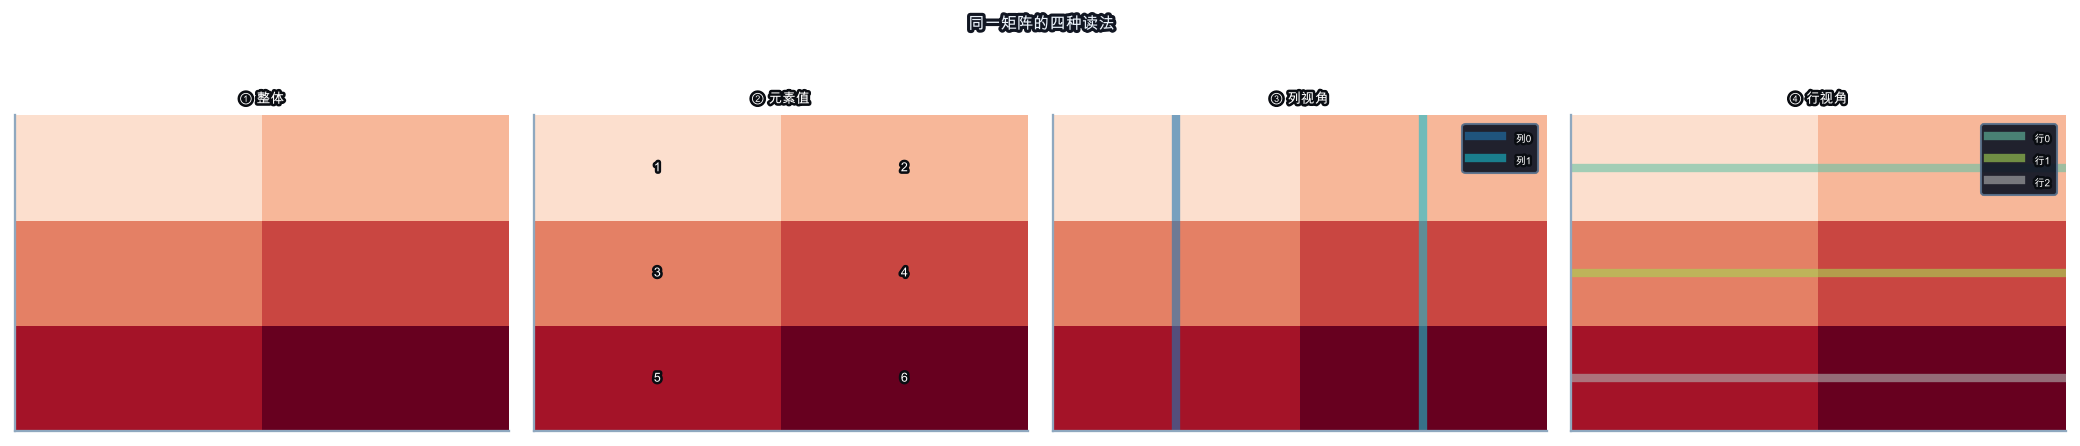

In [5]:
matrix_4ways(np.array([[1,2],[3,4],[5,6]]));

## 停一下：这 4 种看法到底是什么？

拿刚才 `matrix_4ways` 画出的矩阵举例：

```
A = [[1, 2],
     [3, 4],
     [5, 6]]
```

这是一个 3 行 2 列的矩阵（记作 3×2）。同一个 A，可以用 4 种完全不同的眼光去看，就像同一张照片，你可以说它是"一个图片文件"，也可以说它是"几百万个像素点"，还可以说它是"红/绿/蓝三个通道叠在一起"——描述的角度不同，但对象是同一个。

1. **整体看法**：A 就是"一个把 2 维空间映到 3 维空间的操作"，不用关心里面具体是什么数字。
2. **mn 个数字的看法**：A 里面一共有 3×2=6 个数字，逐个摆在网格里：`1, 2, 3, 4, 5, 6`。这是最"死板"的看法——只看数字，不看结构。
3. **n 个列的看法**：把 A 竖着切开，切成 2 条列向量：第 1 列是 `[1, 3, 5]`，第 2 列是 `[2, 4, 6]`。这两列各自是 3 维空间里的一个箭头。
4. **m 个行的看法**：把 A 横着切开，切成 3 条行向量：第 1 行是 `[1, 2]`，第 2 行是 `[3, 4]`，第 3 行是 `[5, 6]`。每一行是 2 维空间里的一个箭头。

它们为什么"都是同一个矩阵"？因为拆法不同，但里面的 6 个数字一个都没多、一个都没少——只是分组的方式变了。就像切蛋糕，横着切、竖着切得到的块形状不同，但蛋糕的原料没变。

**后面真的会怎样切换着看？** 下面第 2 节的"外积"用的是"列 × 行"的看法（第 3、4 种看法搭配起来）；第 3 节的"矩阵×向量"用的是"n 个列"的看法（第 3 种）；第 4 节的秩 1 分解又是"列 × 行"。记住这 4 种看法的名字，后面每次说"从列的角度看"或"从行的角度看"，就知道对应哪一种切法。

## 插播：什么是"秩"？为什么外积总是"秩 1"？

L18 说过"秩 = 信息量"，但这句话有点抽象。换个说法：**秩 = 这个矩阵的列里，有几条是"独立的方向"**。

打个比方：你有一盒彩笔，如果盒子里有红、蓝两种颜色的笔，你能调出很多种颜色（只要按比例混合红和蓝）——这时候"独立的颜色"是 2 种。但如果盒子里全是"深浅不同的红笔"，说到底它们都只是红色的不同浓度，本质上只有 1 种独立的颜色——不管怎么混合，永远调不出蓝色。矩阵的"秩"就是在数这种"独立方向"的个数：秩 2 的矩阵，两列指向不同方向，能张成整个平面；秩 1 的矩阵，所有列都只是同一个方向的不同倍数，永远被"压扁"在一条线上。

现在看外积。外积把一个列向量 `u`（形状 `(m,)`）和一个行向量 `vᵀ`（形状 `(n,)`）相乘，得到一个 m×n 矩阵，规律是：

```
u @ v.T 的第 k 列 = v[k] * u
```

也就是说，结果矩阵的**每一列都是同一个向量 `u` 的倍数**（倍数就是 `v` 里对应的那个数字）。所有列挤在同一条方向上——这正是"秩 1"的定义：只有一个独立方向。下面用代码验证一下，并且对比一个秩 2 的矩阵，看看两者的差别。

In [6]:
import numpy as np

u = np.array([1.0, 2.0, 3.0])   # 列向量 (3,)
v = np.array([4.0, 5.0])        # 行向量的"内容" (2,)

rank1_matrix = np.outer(u, v)   # 3x2 秩1矩阵：u 和 v 的外积
print('外积 u ⊗ v =')
print(rank1_matrix)
print('第1列 / 第2列 =', rank1_matrix[:, 0] / rank1_matrix[:, 1], '  ← 两列是同一方向 u 的倍数')
print('矩阵的秩 =', np.linalg.matrix_rank(rank1_matrix), '(秩1：所有列都指向同一方向)')

print()
rank2_matrix = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])  # 两列方向不同
print('对比：一个秩2矩阵 =')
print(rank2_matrix)
print('矩阵的秩 =', np.linalg.matrix_rank(rank2_matrix), '(秩2：两列指向不同方向，撑起一个平面)')

外积 u ⊗ v =
[[ 4.  5.]
 [ 8. 10.]
 [12. 15.]]
第1列 / 第2列 = [0.8 0.8 0.8]   ← 两列是同一方向 u 的倍数
矩阵的秩 = 1 (秩1：所有列都指向同一方向)

对比：一个秩2矩阵 =
[[1. 0.]
 [0. 1.]
 [1. 1.]]
矩阵的秩 = 2 (秩2：两列指向不同方向，撑起一个平面)


## 2. 向量 × 向量 — 2 种

- **(v1) 内积**：行 · 列 → 一个**标量**
- **(v2) 外积**：列 · 行 → 一个**秩 1 矩阵** ← 所有矩阵分解的积木

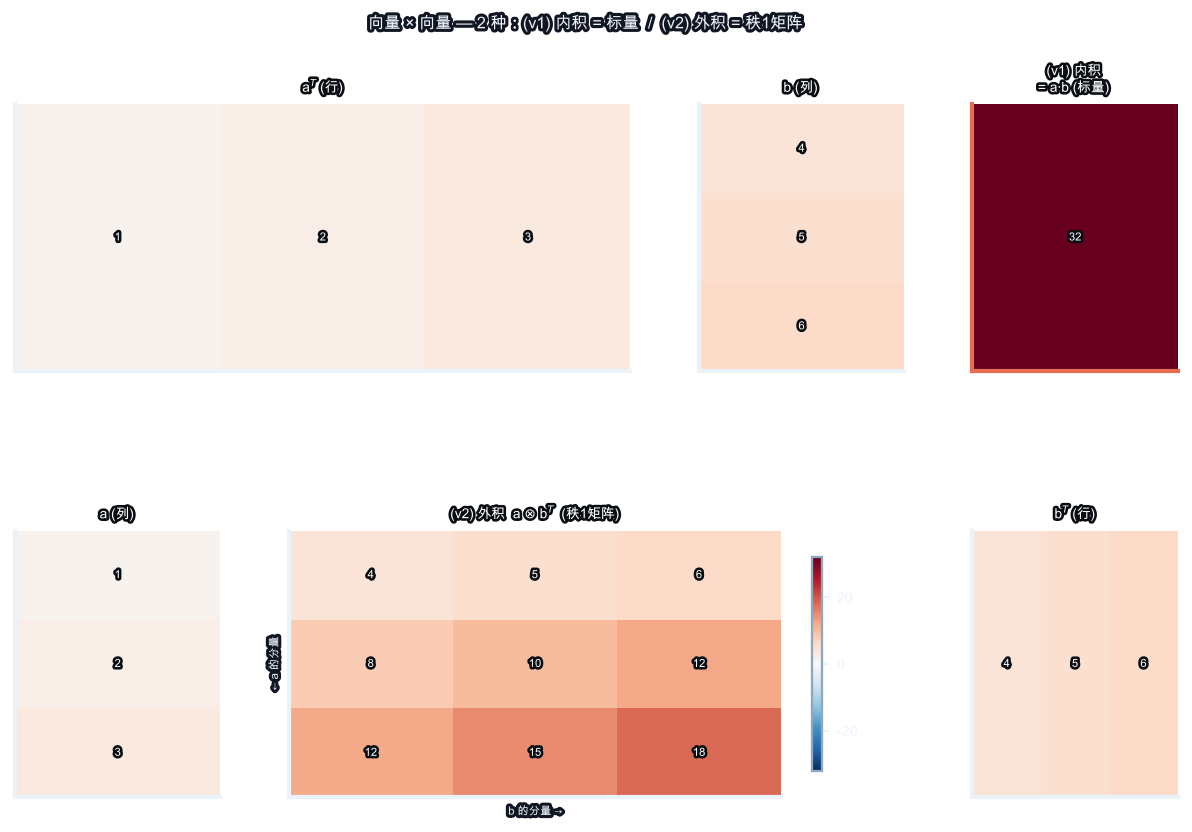

In [7]:
vec_times_vec([1,2,3], [4,5,6]);

**🔗 Aurora**：内积 = 余弦相似度的分子(推荐)；DFT 每个频点也是一次内积。外积(秩1)是连接 SVD / LoRA 的关键。


## 3. 矩阵 × 向量 — 2 种（最重要的一张图）

- **(Mv1)** 每行 · 向量 = 一组点积（dot product）
- **(Mv2)** 把结果看成 **A 的列向量的线性组合**——`Ax` 的灵魂。

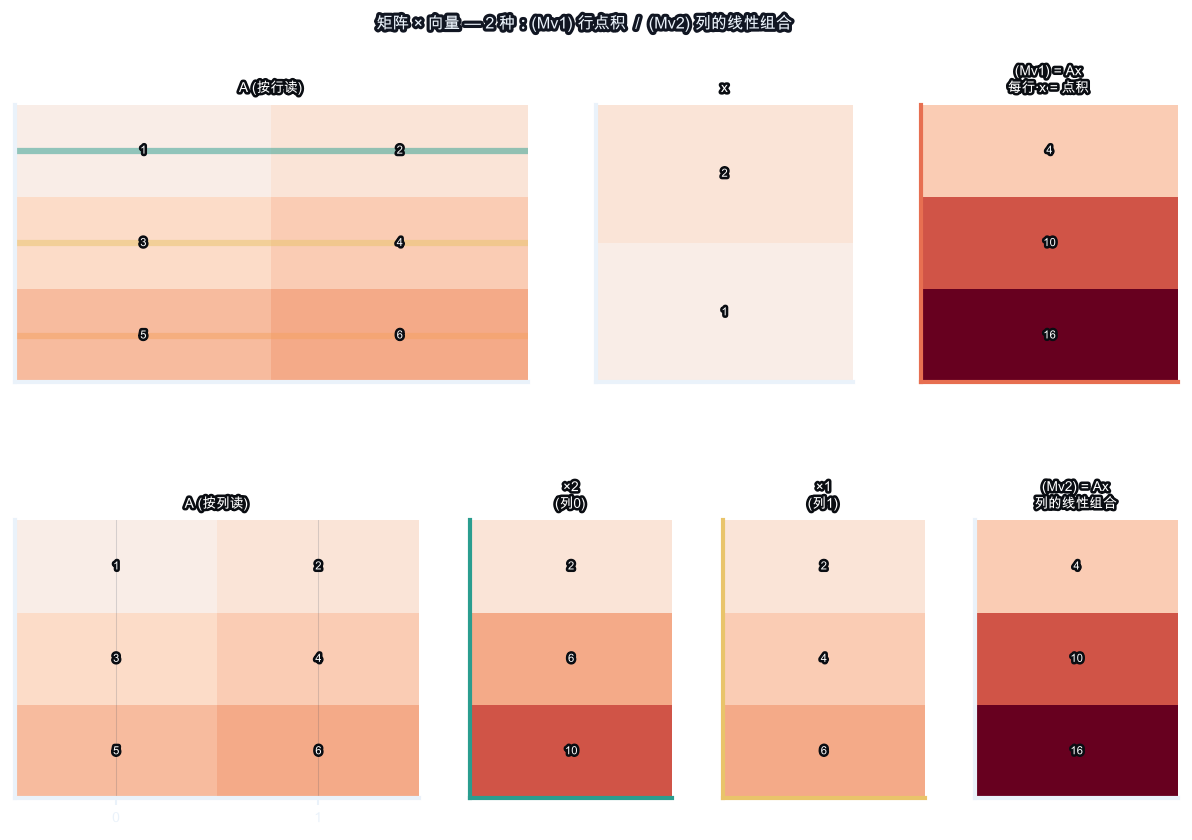

In [8]:
mat_times_vec(np.array([[1,2],[3,4],[5,6]]), [2,1]);

**✏️ 试试**：改变上面的 `[2,1]`，观察右边结果(金色)如何随"列的组合系数"变化。

**🔗 Aurora**：`aurora/audio/transforms.py` 里的 `dft(x)` 就是 `twiddle @ x`（第 64 行），`twiddle[k,n] = exp(-2πjkn/N)` 是 DFT 矩阵 W；`aurora/audio/mel.py` 里的 `mel_filterbank(...)` 返回滤波器矩阵 M，`M @ stft_output` 是同一张图在音频上的直接实例。

### 落地一下：M @ stft_output 具体长什么样？

刚才说 `mel_filterbank(...)` 返回的矩阵 `M` 乘以语谱 `stft_output`，也是"列的线性组合"这张图的实例——但这句话如果没有具体数字，还是有点悬空。下面造一个"迷你版"的例子，把 M 缩小到 2×3（2 个 mel 频段、3 个 FFT 频点），把 `stft_output` 缩小到一个长度为 3 的向量，实际算一遍 `M @ stft_output`。

在真实的 Aurora 代码里，`M` 的**每一列**对应一个 FFT 频点（比如细分出来的 100Hz、200Hz、300Hz 这些频率），列里的数字是"这个频点对每个 mel 频段的贡献权重"；`stft_output` 的**每个分量**是该频点在这一帧信号里的能量。`M @ stft_output` 做的事情是：把每个 FFT 频点的能量，按权重"分配"进对应的 mel 频段，再加总——这正是"列的线性组合"：用 `stft_output` 当系数，去加权 M 的各列，再相加。

In [9]:
# 迷你版 mel 滤波器矩阵：2 个 mel 频段 x 3 个 FFT 频点
M_mini = np.array([
    [0.5, 0.5, 0.0],   # mel 频段 1：只吸收前两个 FFT 频点，各占一半权重
    [0.0, 0.3, 0.7],   # mel 频段 2：偏向第三个 FFT 频点
])
stft_mini = np.array([2.0, 4.0, 6.0])  # 3 个 FFT 频点各自的能量（简化为实数）

mel_out = M_mini @ stft_mini
print('M_mini @ stft_mini =', mel_out)

# 用"列的线性组合"重新算一遍，验证结果一致
manual = (stft_mini[0] * M_mini[:, 0] + stft_mini[1] * M_mini[:, 1]
          + stft_mini[2] * M_mini[:, 2])
print('手动列组合         =', manual)

M_mini @ stft_mini = [3.  5.4]
手动列组合         = [3.  5.4]


### 写代码前，先把变量表补完整

写 `mat_times_vec` 前明确三件事：
- 输入：矩阵 `A`（形状 `(m, n)`）和系数向量 `x`（长度 `n`）
- 关键步骤：分别计算 `A[:, k] * x[k]` 得到每列的贡献，再累加得到 `Ax`
- 返回：各列贡献的图形对象，用于并排展示「列的线性组合」

> **注**：`mat_times_vec` 已在 `aurora.laviz` 中实现，上面是理解其内部结构的概念预习，不要求你自己重写。真正需要动手的是第 5 节「练习：实现 `classify_transform(A)`」。

### 可选深挖：mat_times_vec 内部到底在算什么？

`mat_times_vec` 已经在 `aurora.laviz` 里实现好了，不需要重写它——但如果好奇它的"引擎盖下面"是什么，逻辑其实很朴素：**把矩阵的每一列，乘上系数向量里对应的那个数字，再把这些"被放大/缩小的列"一根根首尾相加**。用大白话说，这就跟去自助餐厅打饭一样：矩阵的每一列是一道菜，系数向量告诉你"这道菜打多少份"，最后把打好的每一份菜叠进同一个盘子，就是 `A @ x` 的结果。

下面手写一遍这个逻辑（不调用 laviz，只用 NumPy），拿第 3 节同样的例子核对结果——如果想自己手算别的例子验证，把这段代码当模板改数字就行。

In [10]:
A_demo = np.array([[1, 2], [3, 4], [5, 6]])
x_demo = np.array([2, 1])

# 手动版 "matrix × vector = 列的线性组合"
total = np.zeros(A_demo.shape[0])
for k in range(A_demo.shape[1]):
    col_contribution = A_demo[:, k] * x_demo[k]
    total = total + col_contribution
    print(f'第{k}列 {A_demo[:, k]} × 系数{x_demo[k]} = {col_contribution}')

print('累加起来   =', total)
print('直接用 @ 算 =', A_demo @ x_demo, '  ← 两者应该一样')

第0列 [1 3 5] × 系数2 = [ 2  6 10]
第1列 [2 4 6] × 系数1 = [2 4 6]
累加起来   = [ 4. 10. 16.]
直接用 @ 算 = [ 4 10 16]   ← 两者应该一样


## 4. 矩阵 × 矩阵 = 秩 1 矩阵之和

`AB = Σ_k (A 的第 k 列) × (B 的第 k 行)`，每项是一个秩 1 矩阵。

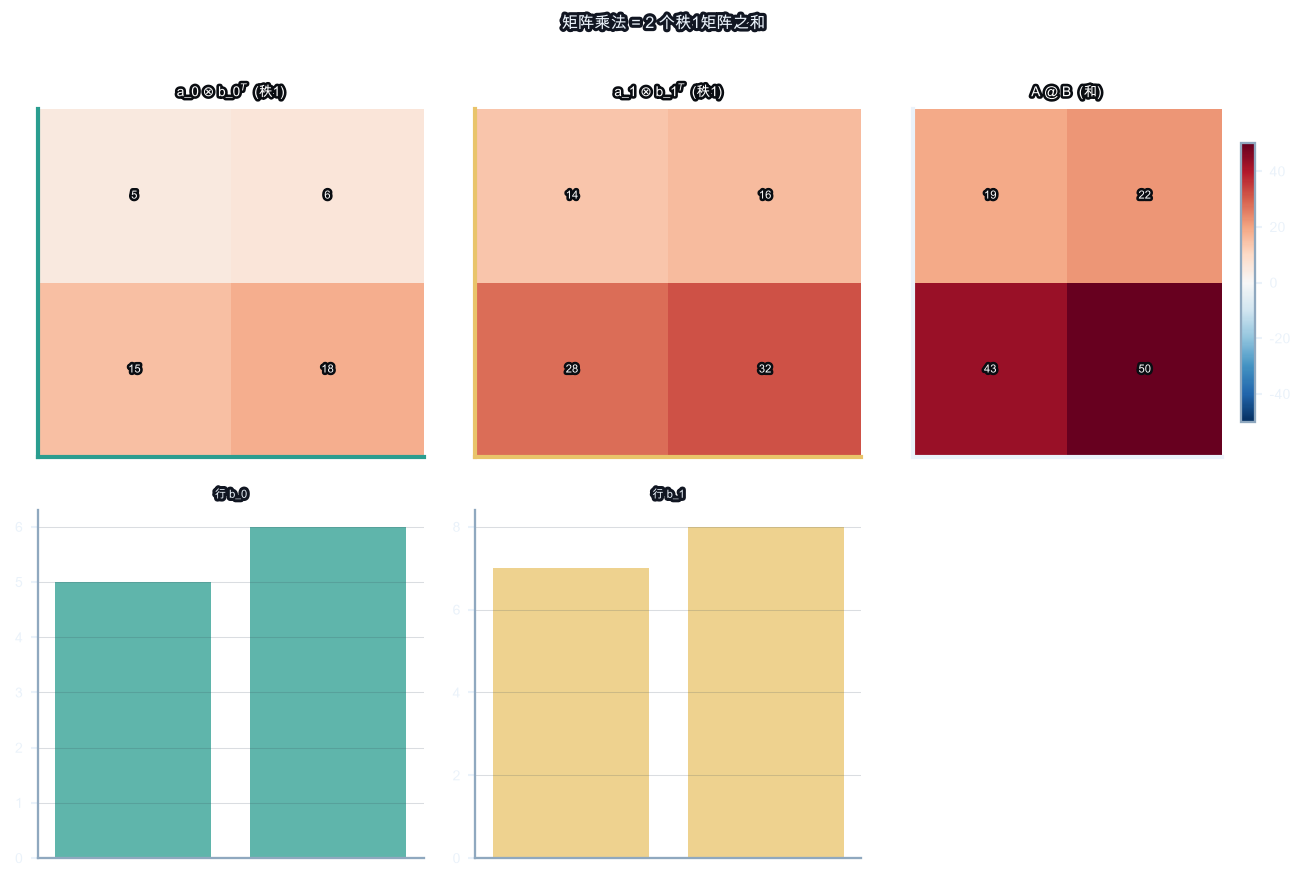

In [11]:
mat_times_mat_rank1(np.array([[1,2],[3,4]]), np.array([[5,6],[7,8]]));

**🔗 Aurora**：这正是 SVD `A=Σσ·uvᵀ`、谱定理 `S=Σλ·qqᵀ`、LoRA 低秩更新的同一张图。下一节（L20 · 矩阵分解图解） 把五大分解都画出来。

In [12]:
A = np.array([[2.0, 1.0], [0.0, 1.0]])
probes = np.array([[1,0], [0,1], [1,1], [-1,2]], dtype=float)
print('矩阵 A 会怎样移动这些向量？')
for v in probes:
    out = A @ v
    print(f'{v} -> {out} | 长度 {np.linalg.norm(v):.2f} -> {np.linalg.norm(out):.2f}')


矩阵 A 会怎样移动这些向量？
[1. 0.] -> [2. 0.] | 长度 1.00 -> 2.00
[0. 1.] -> [1. 1.] | 长度 1.00 -> 1.41
[1. 1.] -> [3. 1.] | 长度 1.41 -> 3.16
[-1.  2.] -> [0. 2.] | 长度 2.24 -> 2.00


### 旋转矩阵为什么长这样？从"基向量转到哪"倒推回去

在往下看"参数实验"之前，先把旋转矩阵的公式自己推一遍，而不是死记硬背。

矩阵由"列"决定——这是第 1 节就讲过的规矩：**只要知道基向量 `[1,0]` 和 `[0,1]` 被送到哪里，整个矩阵就确定了**（因为它们分别正好是矩阵的第 1 列和第 2 列）。所以要造一个"把平面绕原点逆时针转 θ 角"的矩阵，只需要回答两个问题：

1. `[1,0]`（指向 x 轴正方向的单位箭头）转 θ 角后，落在哪里？
2. `[0,1]`（指向 y 轴正方向的单位箭头）转 θ 角后，落在哪里？

把 `[1,0]` 看成一枚指南针，它原来指向角度 0°。绕原点转 θ 角之后，新坐标由三角函数直接给出：`(cos θ, sin θ)`——这正是"单位圆上角度为 θ 的点"的坐标，高中三角函数里已经见过这个定义。同理，`[0,1]` 原来指向角度 90°，转 θ 角后指向角度 `90°+θ`，坐标是 `(cos(90°+θ), sin(90°+θ)) = (-sin θ, cos θ)`（用两角和公式展开就能验证）。

把这两个新坐标当成两"列"拼起来，就是旋转矩阵：

```
R(θ) = [[cos θ, -sin θ],
        [sin θ,  cos θ]]
        ↑第1列      ↑第2列
      ([1,0]转后)  ([0,1]转后)
```

下面用代码验证：转 90° 应该把 `[1,0]` 变成 `[0,1]`（指南针从指向东，转到指向北）。

In [13]:
theta_check = np.radians(90)
R_check = np.array([[np.cos(theta_check), -np.sin(theta_check)],
                     [np.sin(theta_check),  np.cos(theta_check)]])
print('R(90°) @ [1,0] =', np.round(R_check @ np.array([1.0, 0.0]), 6), '  ← 应该约等于 [0,1]')
print('R(90°) @ [0,1] =', np.round(R_check @ np.array([0.0, 1.0]), 6), '  ← 应该约等于 [-1,0]')

R(90°) @ [1,0] = [0. 1.]   ← 应该约等于 [0,1]
R(90°) @ [0,1] = [-1.  0.]   ← 应该约等于 [-1,0]


### 顺便：为什么代码里用 `np.radians(30)` 而不是直接写 30？

`np.cos`、`np.sin` 这些三角函数，在数学和几乎所有编程语言里都约定"输入的角度单位是弧度（radian），不是度数（degree）"。弧度是用"圆弧长度 ÷ 半径"来定义角度的方式：转一整圈（360°）对应的弧度是 `2π`（约 6.28）。如果直接把 `30` 丢给 `np.cos`，NumPy 会把它当成"30 弧度"（差不多转了 4 圈多），而不是"30 度"，算出来的旋转会完全不对。`np.radians(30)` 做的事情就是"把 30 度换算成对应的弧度值"（`30 × π/180 ≈ 0.5236`），换算之后再喂给 `cos`/`sin` 才是对的。

## 参数实验：用旋转矩阵（rotation matrix）验证正交矩阵保距

在第 3 节（`mat_times_vec`）的代码里，把矩阵替换成旋转矩阵（θ = 30°）：

```python
theta = np.radians(30)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
```

观察基向量 `[1,0]` 和 `[0,1]` 均被旋转 30°，但 `np.linalg.norm(R @ v) == np.linalg.norm(v)` 成立——这是**正交矩阵保距**的直观验证。对比原矩阵 `[[2,1],[0,1]]`：它同时改变方向和模长（非正交）。

### 手动推一遍：R@Rᵀ=I 为什么就等于"长度不变"？

上面说"`R@Rᵀ=I` 是正交矩阵保距的直观验证"，这里把推导过程完整摆出来，不跳步骤。

先回忆一下：一个向量 `v` 的长度平方，可以写成"它和自己的内积"：`‖v‖² = v · v = vᵀv`（每个分量自己乘自己，再加起来，正好是长度平方的定义——勾股定理的高维版本）。

现在向量被 R 变换成了 `Rv`，它的新长度平方是：

```
‖Rv‖² = (Rv)ᵀ(Rv)
```

转置有一条规则："括号里乘积的转置，等于把每一项分别转置后交换顺序"，所以 `(Rv)ᵀ = vᵀRᵀ`。代入：

```
‖Rv‖² = (Rv)ᵀ(Rv) = vᵀ Rᵀ R v
```

关键的一步来了：如果 R 满足 `R@Rᵀ=I`（正交矩阵的定义是 R 和它的转置互为逆矩阵，即 `RRᵀ=RᵀR=I`），那么 `Rᵀ R` 这一段就直接等于单位矩阵 `I`：

```
‖Rv‖² = vᵀ (RᵀR) v = vᵀ I v = vᵀ v = ‖v‖²
```

两边开平方，得到 `‖Rv‖ = ‖v‖`——这就是"正交矩阵保距"的完整证明：因为 `RᵀR` 这一步"抵消"成了单位矩阵，中间的变换对长度没有任何影响。下面的断言 cell 会用具体数字（`v=[3,4]`）再验证一次这个结论。

=== 旋转矩阵 R(30°) × [1,0] ===
=== 缩放矩阵 S × [1,0] ===
=== 剪切矩阵 K × [1,0] ===


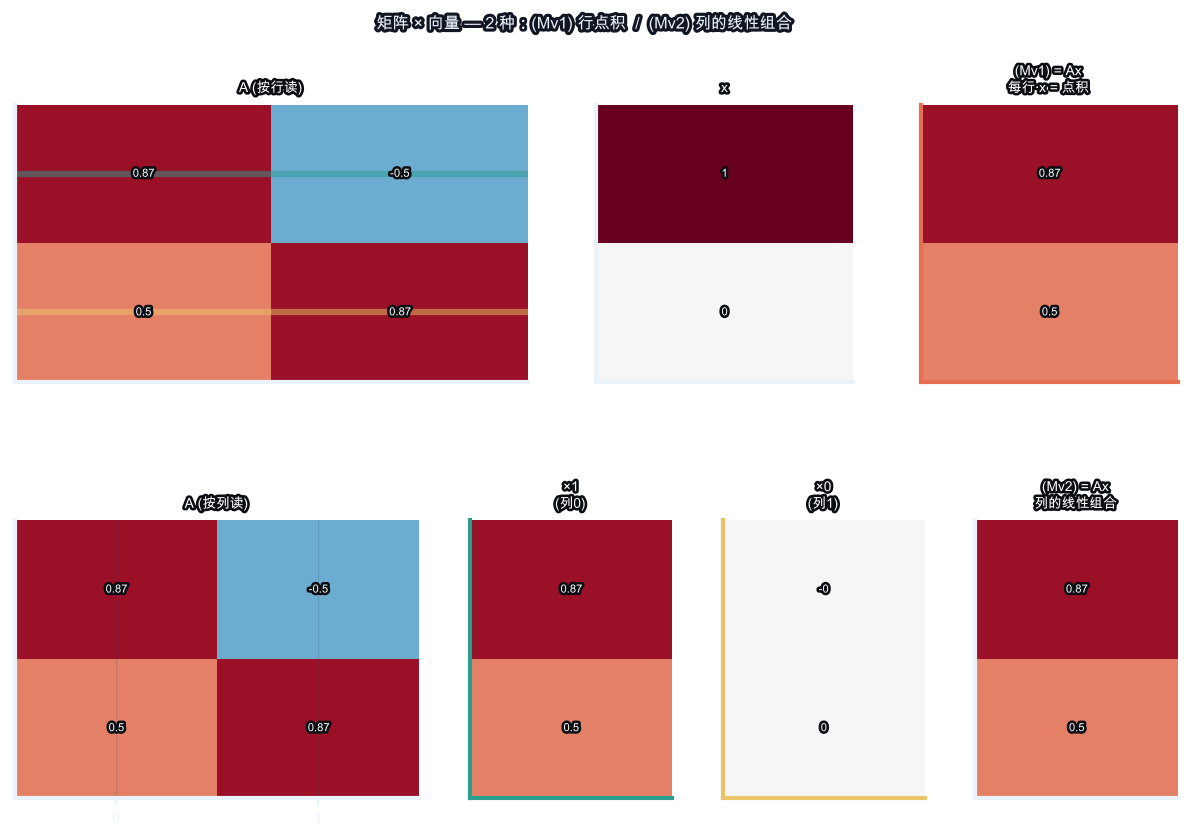

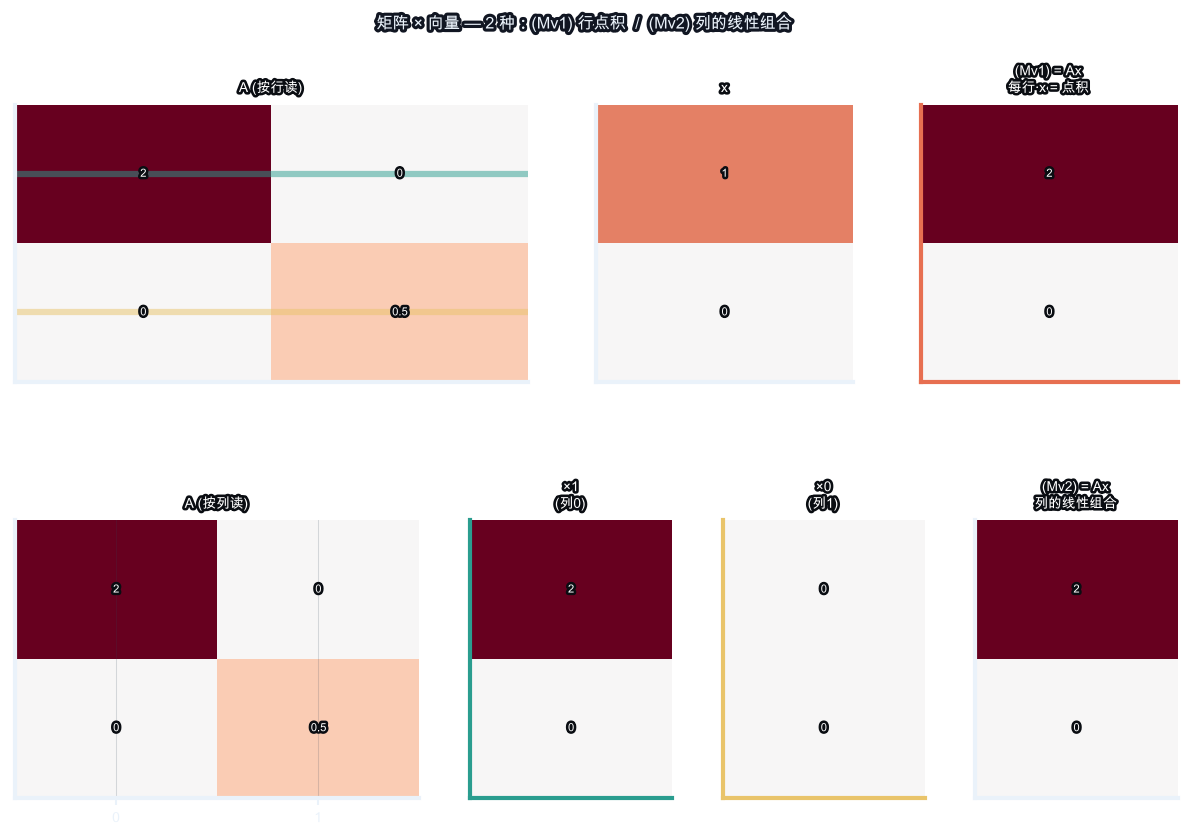

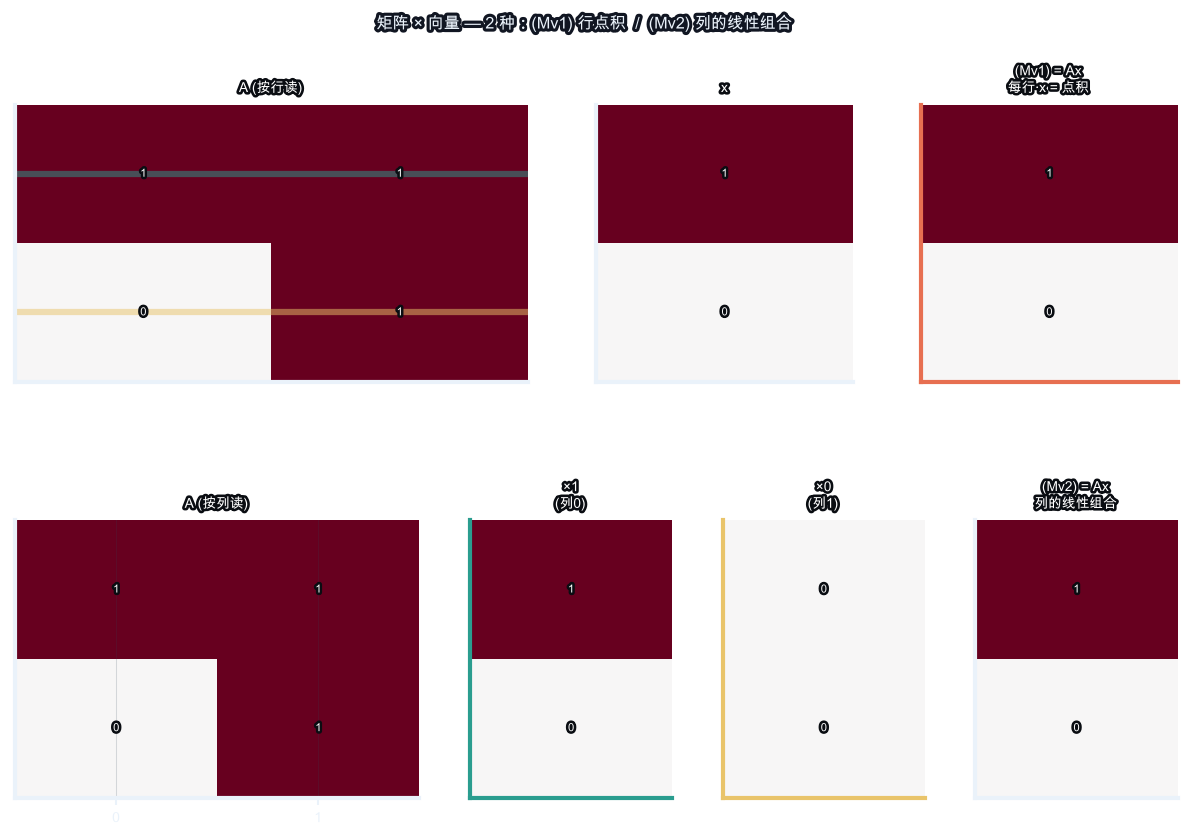

In [14]:
# ✅ 旋转 / 缩放 / 剪切 用 laviz 实际可视化（兑现标题承诺）
theta = np.radians(30)
R_30   = np.array([[np.cos(theta), -np.sin(theta)],   # 旋转 30°
                   [np.sin(theta),  np.cos(theta)]])
S_2    = np.array([[2., 0.], [0., 0.5]])              # x 放大 2×，y 缩小 0.5×
K_1    = np.array([[1., 1.], [0., 1.]])              # 水平剪切 k=1

v_unit = [1., 0.]
print('=== 旋转矩阵 R(30°) × [1,0] ===')
mat_times_vec(R_30, v_unit)
print('=== 缩放矩阵 S × [1,0] ===')
mat_times_vec(S_2, v_unit)
print('=== 剪切矩阵 K × [1,0] ===')
mat_times_vec(K_1, v_unit)


### det(A) 到底在量什么？——面积的"缩放倍数 + 是否翻面"

`det`（行列式）这个数字，几何上回答一个问题：**这个矩阵把"面积"放大了多少倍，以及有没有把图形"翻过来"**。

具体来说：在 2D 里，取基向量 `[1,0]` 和 `[0,1]` 围成的正方形，面积是 1。矩阵 A 把这两个基向量变成 A 的两列，这两列新箭头围成一个平行四边形——`det(A)` 的**绝对值**，就是这个平行四边形的面积（相当于原正方形面积的多少倍）。而 `det(A)` 的**正负号**，标记的是"定向"有没有被翻转：基向量 `[1,0]→[0,1]` 原本是"逆时针"排列的，如果变换后两个新列还是逆时针排列（比如单纯旋转），det 就是正的；如果变换把它们的相对顺序"翻"成了顺时针（比如照镜子），det 就是负的——就像把一张写了字的纸翻到背面，字变成了镜像，"翻面"这个动作正是 det 变负号的几何来源。

用第 3 节的缩放矩阵 `S = [[2,0],[0,0.5]]` 举例：det(S) = 2×0.5 = 1.0，意思是"面积先被放大 2 倍、又缩小到一半，合起来面积不变，也没有翻面"。而反射矩阵 `[[0,1],[1,0]]`（把 x、y 互换，等价于沿 y=x 这条线照镜子）det = 0×0 − 1×1 = −1：绝对值 1 表示面积没变，负号表示"翻面"了。

下面用代码把"旋转"和"反射"的 det 走一遍，对比它们的正负号，再看一个各向异性缩放的例子，确认"det 的绝对值就是面积放大倍数"。

In [15]:
theta_demo = np.radians(40)
R_demo = np.array([[np.cos(theta_demo), -np.sin(theta_demo)],
                    [np.sin(theta_demo),  np.cos(theta_demo)]])
Refl_demo = np.array([[0., 1.], [1., 0.]])

print('旋转矩阵 R(40°) 的 det =', np.linalg.det(R_demo), '  (面积不变，没有翻面 → 正号)')
print('反射矩阵 [[0,1],[1,0]] 的 det =', np.linalg.det(Refl_demo), '  (面积不变，但翻面了 → 负号)')

S_demo = np.array([[2., 0.], [0., 3.]])
print('缩放矩阵 [[2,0],[0,3]] 的 det =', np.linalg.det(S_demo), '  (面积放大 2x3=6 倍，这个 6 就是 det)')

旋转矩阵 R(40°) 的 det = 1.0   (面积不变，没有翻面 → 正号)
反射矩阵 [[0,1],[1,0]] 的 det = -1.0   (面积不变，但翻面了 → 负号)
缩放矩阵 [[2,0],[0,3]] 的 det = 6.0   (面积放大 2x3=6 倍，这个 6 就是 det)


### "保距"和"保面积"是两回事——旋转 vs 剪切对比

容易把"变换保持了什么性质"混在一起，这里把两个概念拆开对比：

- **保距**（长度不变）：只有正交矩阵才有这个性质（`R@Rᵀ=I`），旋转和反射都属于这一类。上面已经证明过：`‖Rv‖=‖v‖`。
- **保面积**（det 的绝对值=1）：只要求"整体面积的缩放倍数是 1"，并不要求每个向量的长度不变。剪切矩阵就是典型例子。

想象拿一副扑克牌整整齐齐叠成一摞（一个矩形截面），然后用手往旁边推一下顶部，让整摞牌变成一个斜的平行四边形——每张牌本身没有旋转也没有形变，牌摞占的"面积"没有变，但摞的外形从矩形变成了斜的，边长也变了。这就是剪切：面积不变，但角度、长度都可能变。

下面用代码验证：剪切矩阵 `K=[[1,1],[0,1]]` 满足 det=1（保面积），但 `K@Kᵀ ≠ I`（不保距，向量长度会变）。

In [16]:
K_demo = np.array([[1., 1.], [0., 1.]])
v_demo = np.array([0.0, 1.0])

print('K 的 det =', np.linalg.det(K_demo), '  ← 面积不变(保面积)')
print('K @ Kᵀ =')
print(K_demo @ K_demo.T)
print('是否等于单位矩阵 I？', np.allclose(K_demo @ K_demo.T, np.eye(2)), '  ← 不是，所以剪切不保距')
print('‖v‖ =', np.linalg.norm(v_demo), '   ‖K@v‖ =', np.linalg.norm(K_demo @ v_demo), '  ← 长度确实变了')

K 的 det = 1.0   ← 面积不变(保面积)
K @ Kᵀ =
[[2. 1.]
 [1. 1.]]
是否等于单位矩阵 I？ False   ← 不是，所以剪切不保距
‖v‖ = 1.0    ‖K@v‖ = 1.4142135623730951   ← 长度确实变了


In [17]:
import numpy as np

# 几何变换数学性质断言（独立运行，无需学生实现）
theta = np.radians(30)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
Refl = np.array([[0., 1.], [1., 0.]])
Scale = np.array([[2., 0.], [0., 0.5]])
Shear = np.array([[1., 1.], [0., 1.]])

# 旋转矩阵：正交 + det=+1 + 保长度
assert np.allclose(R @ R.T, np.eye(2), atol=1e-12), "旋转矩阵应满足 R@Rᵀ=I"
assert np.isclose(np.linalg.det(R), 1.0, atol=1e-12), "旋转矩阵 det 应为 +1"
v = np.array([3., 4.])
assert np.isclose(np.linalg.norm(R @ v), np.linalg.norm(v), atol=1e-12), "旋转保持向量长度"
print(f"旋转矩阵 ✅  R@Rᵀ=I, det={np.linalg.det(R):.4f}, ||R@v||=||v||={np.linalg.norm(v):.4f}")

# 反射矩阵：正交 + det=-1
assert np.allclose(Refl @ Refl.T, np.eye(2), atol=1e-12), "反射矩阵应满足 Refl@Reflᵀ=I"
assert np.isclose(np.linalg.det(Refl), -1.0, atol=1e-12), "反射矩阵 det 应为 -1"
print(f"反射矩阵 ✅  Refl@Reflᵀ=I, det={np.linalg.det(Refl):.4f}")

# 缩放矩阵：对角 + det = 对角元素之积
det_scale = np.linalg.det(Scale)
assert np.isclose(det_scale, Scale[0,0] * Scale[1,1], atol=1e-12), "缩放矩阵 det = 对角元素积"
assert np.isclose(Scale[0,1], 0.0) and np.isclose(Scale[1,0], 0.0), "缩放矩阵是对角矩阵"
print(f"缩放矩阵 ✅  det={det_scale:.4f} = {Scale[0,0]}×{Scale[1,1]}，纯对角结构")

# 剪切矩阵：det=1（保面积）但非正交
assert np.isclose(np.linalg.det(Shear), 1.0, atol=1e-12), "剪切矩阵保面积 det=1"
assert not np.allclose(Shear @ Shear.T, np.eye(2), atol=1e-4), "剪切矩阵不是正交矩阵"
print(f"剪切矩阵 ✅  det=1（保面积），但 K@Kᵀ≠I（改变角度）")
print("\n所有几何变换性质验证通过 ✅")

旋转矩阵 ✅  R@Rᵀ=I, det=1.0000, ||R@v||=||v||=5.0000
反射矩阵 ✅  Refl@Reflᵀ=I, det=-1.0000
缩放矩阵 ✅  det=1.0000 = 2.0×0.5，纯对角结构
剪切矩阵 ✅  det=1（保面积），但 K@Kᵀ≠I（改变角度）

所有几何变换性质验证通过 ✅


## 5. ✏️ 练习：实现 `classify_transform(A)`

给定一个 2×2 矩阵，判断它代表哪种几何变换：

- **rotation**（旋转）：`A @ Aᵀ ≈ I` 且 `det(A) ≈ +1`
- **reflection**（反射）：`A @ Aᵀ ≈ I` 且 `det(A) ≈ −1`
- **scaling**（缩放）：对角矩阵（`A[0,1] ≈ A[1,0] ≈ 0`）
- **shear**（剪切）：其他情况

**提示**：先算 `np.linalg.det(A)` 和 `A @ A.T`，再逐条判断。

**⚠️ 顺序很重要**：必须先判断正交性（步骤1 rotation，步骤2 reflection），再判断对角（步骤3 scaling）。如果先检查对角，`[[0,1],[1,0]]` 也可能被误判——请严格按上述顺序实现。

### 亲眼看一遍：判断顺序错了会发生什么

光说"顺序很重要"比较抽象，下面直接跑两条判断路径，对着反射矩阵 `[[0,1],[1,0]]` 走一遍，看看错误顺序会在哪一步"看错"。

In [18]:
M_test = np.array([[0., 1.], [1., 0.]])  # 反射矩阵：沿 y=x 照镜子

is_orthogonal = np.allclose(M_test @ M_test.T, np.eye(2))
is_diagonal = np.isclose(M_test[0, 1], 0.0) and np.isclose(M_test[1, 0], 0.0)
det_val = np.linalg.det(M_test)

print('M_test =')
print(M_test)
print('是否正交 (M@Mᵀ≈I)？', is_orthogonal)
print('是否对角 (非对角元≈0)？', is_diagonal)
print('det(M_test) =', det_val)

print()
print('--- ❌ 错误顺序：先检查"是否对角" ---')
if is_diagonal:
    print('判为 scaling')
else:
    print('不是对角矩阵 → 判为 shear   ← 错！M_test 明明是反射，却被归到剪切里')

print()
print('--- ✅ 正确顺序：先检查"是否正交" ---')
if is_orthogonal and np.isclose(det_val, 1.0):
    print('判为 rotation')
elif is_orthogonal and np.isclose(det_val, -1.0):
    print('判为 reflection   ← 对！先确认正交，再看 det=-1，正确识别为反射')
elif is_diagonal:
    print('判为 scaling')
else:
    print('判为 shear')

M_test =
[[0. 1.]
 [1. 0.]]
是否正交 (M@Mᵀ≈I)？ True
是否对角 (非对角元≈0)？ False
det(M_test) = -1.0

--- ❌ 错误顺序：先检查"是否对角" ---
不是对角矩阵 → 判为 shear   ← 错！M_test 明明是反射，却被归到剪切里

--- ✅ 正确顺序：先检查"是否正交" ---
判为 reflection   ← 对！先确认正交，再看 det=-1，正确识别为反射


**为什么会这样？** `[[0,1],[1,0]]` 这个矩阵，对角线上（左上、右下）两个数字都是 0，而对角线**外面**（右上、左下）两个数字都是 1——"是否对角"这条检查看的正是"对角线外面是不是 0"，而这个矩阵刚好相反，所以它会被"对角检查"正确地判定为"不是对角矩阵"，接着（按错误顺序）直接掉进 shear 分支，跳过了它本该属于的 reflection。只有先做"正交检查"，才能在它还没走到 shear 分支之前，就用 `det=-1` 把它正确地识别成 reflection。这也是为什么练习里反复强调：**先判正交（rotation/reflection），才判对角（scaling），剩下的才归为 shear**——顺序换了，中间的分支会把本该属于前面类别的矩阵，拦截进错误的桶里。

In [19]:
import numpy as np

def classify_transform(A, tol=1e-9):
    """返回 'rotation' | 'reflection' | 'scaling' | 'shear'"""
    A = np.asarray(A, float)
    # ✏️ TODO: 用 det + AᵀA 判断变换类型
    raise NotImplementedError('请实现 classify_transform')

# 验证
theta = np.pi / 3
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])   # 旋转 60°
Refl = np.array([[0., 1.], [1., 0.]])            # 沿 y=x 反射（det=-1，非对角，不会被误判为缩放）
Scale = np.array([[2., 0.], [0., 3.]])            # 各向异性缩放
Shear = np.array([[1., 1.], [0., 1.]])            # 剪切

try:
    assert classify_transform(R) == 'rotation',    f'旋转矩阵识别错误: {classify_transform(R)}'
    assert classify_transform(Refl) == 'reflection', f'反射矩阵识别错误: {classify_transform(Refl)}'
    assert classify_transform(Scale) == 'scaling',  f'缩放矩阵识别错误: {classify_transform(Scale)}'
    assert classify_transform(Shear) == 'shear',    f'剪切矩阵识别错误: {classify_transform(Shear)}'
    print('✅ 通过：旋转/反射/缩放/剪切 全部识别正确')
except (NotImplementedError, TypeError):
    print('⬆️  先把 classify_transform 实现完再运行')


⬆️  先把 classify_transform 实现完再运行


## 本课收束

现在能用 `laviz` 把 `A @ x` 画成「A 的各列乘以 x 的系数再相加」，把 `A @ B` 画成若干秩1矩阵叠加。前者是矩阵×向量的列视角，后者是矩阵×矩阵的秩1分解视角——两者共享同一张图。这两张图在 Aurora 中对应 `mel_filterbank @ stft_output` 的频率映射和 DFT 矩阵 `W @ x` 的频谱计算。下一节（L20 · 矩阵分解图解） 会用同一套图语把 SVD 和特征分解展开，到时候「秩1矩阵之和」的结构会直接复用。

### 一张表：内积和外积在 Aurora 里各自负责什么

| | 输入形状 | 输出 | 在 Aurora 里对应什么 | 用在哪种运算里 |
|---|---|---|---|---|
| **内积**（行·列→标量） | 两个长度相同的向量 | 一个数字 | DFT 每个频点的值 = 信号和一条"探测波"的内积；推荐系统里两个向量的余弦相似度分子 | 矩阵×向量时"每行·向量"的算法（第 3 节 (Mv1) 视角） |
| **外积**（列·行→秩1矩阵） | 一个列向量 + 一个行向量 | 一个矩阵（秩1） | SVD 分解 `A=Σσ·uvᵀ` 里的每一项；LoRA 用一对"瘦"矩阵去逼近一次权重更新（weight update），本质也是秩1（或低秩）叠加 | 矩阵×矩阵时"列×行求和"的算法（第 4 节） |

简单说：**内积是在"压缩"——把一堆数字浓缩成一个数**（衡量两个向量有多像、或算一次频率成分的强弱）；**外积是在"铺开"——把两个向量铺成一整个矩阵**（构造出分解里的"基本积木"）。矩阵×向量那张图（第 3 节）背后用的是内积的逐行版本；矩阵×矩阵那张图（第 4 节）背后用的是外积的逐项求和。下一课（L20）会看到，SVD 就是把一个矩阵拆成好几个"外积积木"叠起来，而每个积木的"含金量"由一个奇异值 σ 决定。

In [ ]:
# ✏️ 本课自评
l19_review = {
    "matvec_picture_understood": None,  # 能解释 A@x 的列线性组合图？True/False
    "matmul_rank1_intuition":    None,  # 理解 A@B 的秩1叠加视角？True/False
    "classify_transform_done":   None,  # classify_transform 实现并通过断言？True/False
    "transform_det_sign":        None,  # 知道旋转 det=+1、反射 det=-1？True/False
}

unfilled = [k for k, v in l19_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l19_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L19 全部通关！进入 L20：矩阵分解图解')


---

→ **下一课**　[L20 · 分解图谱](L20_visual_factorizations.ipynb)

> 下节课将学习 **分解图谱**：LU / QR / SVD 三种分解的几何意义对比。